# **Business Insights**


# Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
COLORS = ['#2196F3','#FF9800','#4CAF50','#E91E63','#9C27B0']

# ── Load cleaned CSVs ─────────────────────────────────────────
BASE = '../data/cleaned_data/' 

cust   = pd.read_csv(BASE + 'customers_clean.csv',    parse_dates=['BirthDate','JoinDate'])
prod   = pd.read_csv(BASE + 'products_clean.csv')
stores = pd.read_csv(BASE + 'stores_clean.csv')
trans  = pd.read_csv(BASE + 'transactions_clean.csv', parse_dates=['Date'])

print('Data loaded!')
print(f'  Customers    : {len(cust)}')
print(f'  Products     : {len(prod)}')
print(f'  Stores       : {len(stores)}')
print(f'  Transactions : {len(trans)}')

# Enrich transactions with product and store info
trans_full = trans.merge(prod[['ProductID','Category','SubCategory','ProfitMargin']], on='ProductID')
trans_full = trans_full.merge(stores[['StoreID','StoreName','Region']], on='StoreID')
trans_full = trans_full.merge(cust[['CustomerID','Gender','Age']], on='CustomerID')

print('\nEnriched transaction table ready!')

Data loaded!
  Customers    : 200
  Products     : 50
  Stores       : 5
  Transactions : 5000

Enriched transaction table ready!


# Monthly Revenue Trend

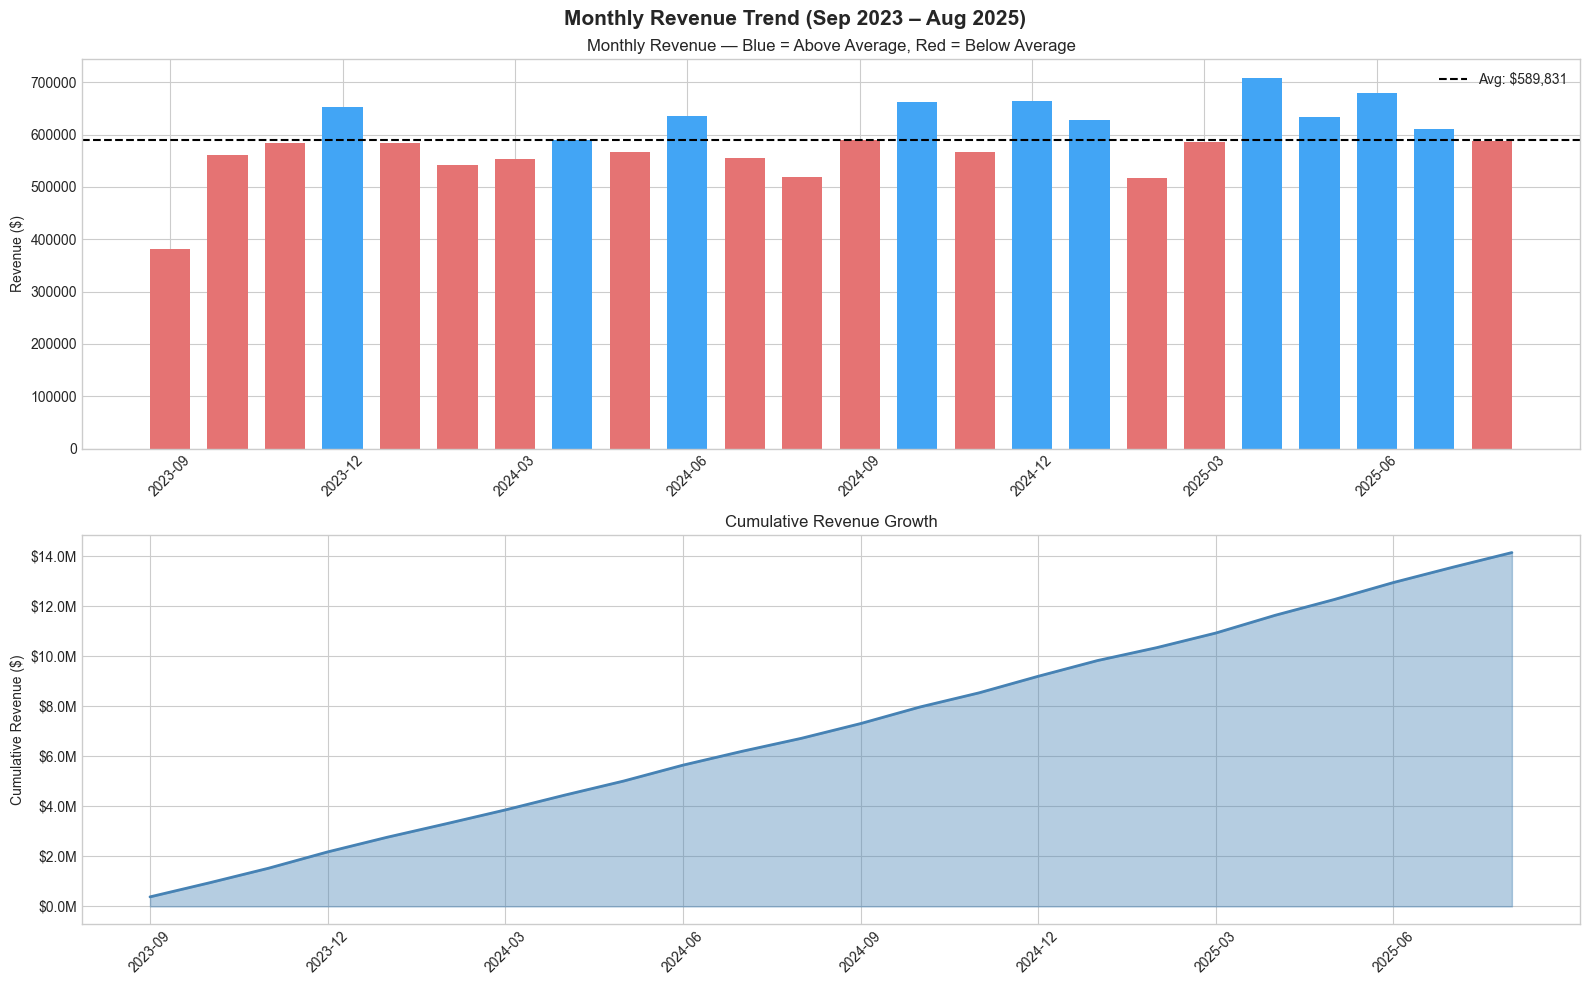

Saved: charts/revenue_trend.png


In [2]:
# Monthly Revenue with Trend Line
monthly = trans.groupby(trans['Date'].dt.to_period('M'))['TotalAmount'].sum().reset_index()
monthly.columns = ['Month', 'Revenue']
monthly['Month_str'] = monthly['Month'].astype(str)

# Exclude partial Sept 2025
monthly_full = monthly[monthly['Month_str'] != '2025-09'].copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Monthly Revenue Trend (Sep 2023 – Aug 2025)', fontsize=15, fontweight='bold')

# Bar chart (blue = above average, red = below average)
bar_colors = ['#E57373' if r < monthly_full['Revenue'].mean() else '#42A5F5'
              for r in monthly_full['Revenue']]
axes[0].bar(monthly_full['Month_str'], monthly_full['Revenue'], color=bar_colors, width=0.7)
axes[0].axhline(monthly_full['Revenue'].mean(), color='black', linestyle='--', linewidth=1.5,
                label=f'Avg: ${monthly_full["Revenue"].mean():,.0f}')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_title('Monthly Revenue — Blue = Above Average, Red = Below Average')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)
tick_pos = range(0, len(monthly_full), 3)
axes[0].set_xticks(list(tick_pos))
axes[0].set_xticklabels([monthly_full['Month_str'].iloc[i] for i in tick_pos], rotation=45)

# Cumulative revenue
monthly_full = monthly_full.copy()
monthly_full['Cumulative'] = monthly_full['Revenue'].cumsum()
axes[1].fill_between(range(len(monthly_full)), monthly_full['Cumulative'],
                     alpha=0.4, color='steelblue')
axes[1].plot(range(len(monthly_full)), monthly_full['Cumulative'],
             color='steelblue', linewidth=2)
axes[1].set_ylabel('Cumulative Revenue ($)')
axes[1].set_title('Cumulative Revenue Growth')
axes[1].set_xticks(list(tick_pos))
axes[1].set_xticklabels([monthly_full['Month_str'].iloc[i] for i in tick_pos], rotation=45)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('../charts/revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: charts/revenue_trend.png')

# Year-over-Year Comparison

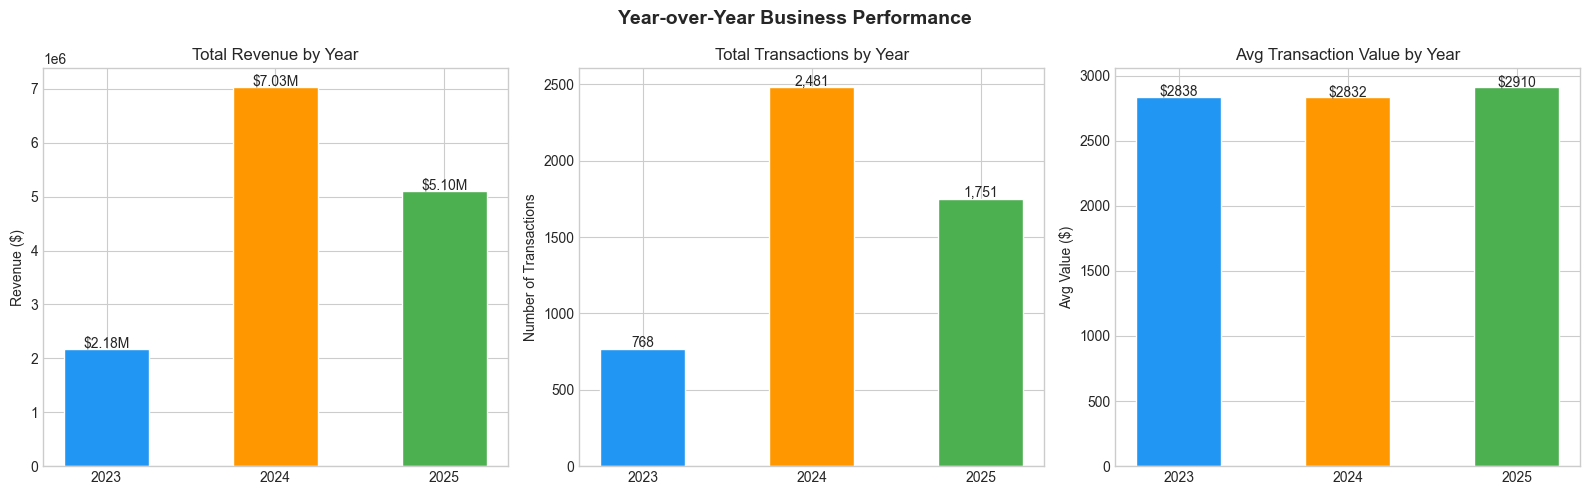

Saved: charts/yearly_comparison.png


In [3]:
# Year-over-Year Revenue Comparison
yearly = trans.groupby(trans['Date'].dt.year)['TotalAmount'].agg(['sum','count','mean']).reset_index()
yearly.columns = ['Year', 'Revenue', 'Transactions', 'AvgValue']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Year-over-Year Business Performance', fontsize=14, fontweight='bold')

bar_kw = dict(width=0.5, edgecolor='white')
years  = yearly['Year'].astype(str)

axes[0].bar(years, yearly['Revenue'], color=COLORS[:3], **bar_kw)
axes[0].set_title('Total Revenue by Year')
axes[0].set_ylabel('Revenue ($)')
for i, v in enumerate(yearly['Revenue']):
    axes[0].text(i, v + 30000, f'${v/1e6:.2f}M', ha='center', fontsize=10)

axes[1].bar(years, yearly['Transactions'], color=COLORS[:3], **bar_kw)
axes[1].set_title('Total Transactions by Year')
axes[1].set_ylabel('Number of Transactions')
for i, v in enumerate(yearly['Transactions']):
    axes[1].text(i, v + 10, f'{v:,}', ha='center', fontsize=10)

axes[2].bar(years, yearly['AvgValue'], color=COLORS[:3], **bar_kw)
axes[2].set_title('Avg Transaction Value by Year')
axes[2].set_ylabel('Avg Value ($)')
for i, v in enumerate(yearly['AvgValue']):
    axes[2].text(i, v + 10, f'${v:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../charts/yearly_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: charts/yearly_comparison.png')

# Seasonal Pattern

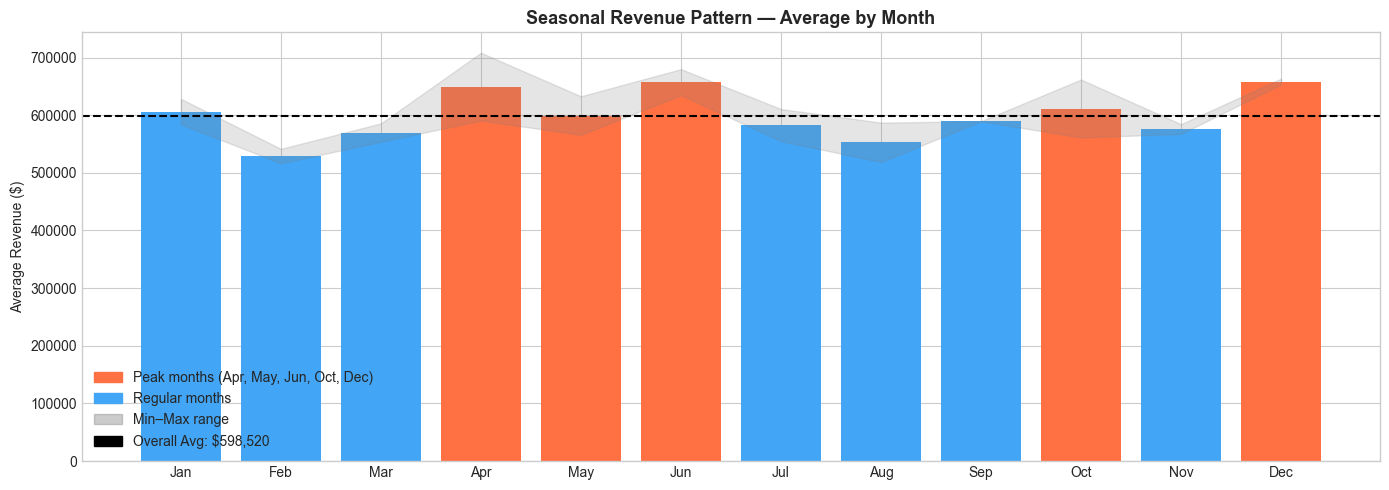

Saved: charts/seasonal_pattern.png


In [5]:
# Ensure Date column is datetime
trans['Date'] = pd.to_datetime(trans['Date'])

# -------------------------------------------
# Seasonal Pattern (Avg Revenue by Month)
# Exclude partial months: Sep 2023 and Sep 2025
# -------------------------------------------

trans_clean = trans[~((trans['Date'].dt.year == 2023) & (trans['Date'].dt.month == 9))].copy()
trans_clean = trans_clean[~((trans_clean['Date'].dt.year == 2025) & (trans_clean['Date'].dt.month == 9))]

# Create Year and Month columns
trans_clean['Year'] = trans_clean['Date'].dt.year
trans_clean['Month'] = trans_clean['Date'].dt.month

# Monthly revenue per year
seasonal = trans_clean.groupby(['Year','Month'])['TotalAmount'].sum().reset_index()
seasonal.columns = ['Year', 'Month', 'Revenue']

# Average revenue per calendar month
seasonal_avg = seasonal.groupby('Month')['Revenue'].agg(['mean','min','max']).reset_index()

# Month names
month_names  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seasonal_avg['MonthName'] = [month_names[m-1] for m in seasonal_avg['Month']]

# -------------------------------------------
# Plot chart
# -------------------------------------------

fig, ax = plt.subplots(figsize=(14,5))

# Highlight peak months
peak_months = [4,5,6,10,12]
bar_colors = ['#FF7043' if m in peak_months else '#42A5F5' for m in seasonal_avg['Month']]

# Bar chart
ax.bar(seasonal_avg['MonthName'], seasonal_avg['mean'], color=bar_colors)

# Min–Max range shading
ax.fill_between(
    range(len(seasonal_avg)),
    seasonal_avg['min'],
    seasonal_avg['max'],
    alpha=0.2,
    color='gray'
)

# Overall average line
overall_avg = seasonal_avg["mean"].mean()
ax.axhline(
    overall_avg,
    color='black',
    linestyle='--',
    label=f'Overall Avg: ${overall_avg:,.0f}'
)

# Titles
ax.set_title('Seasonal Revenue Pattern — Average by Month', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Revenue ($)')

# Legend
ax.legend(handles=[
    mpatches.Patch(color='#FF7043', label='Peak months (Apr, May, Jun, Oct, Dec)'),
    mpatches.Patch(color='#42A5F5', label='Regular months'),
    mpatches.Patch(color='gray', label='Min–Max range', alpha=0.4),
    mpatches.Patch(color='black', label=f'Overall Avg: ${overall_avg:,.0f}')
])

plt.tight_layout()

# Save chart
plt.savefig('../charts/seasonal_pattern.png', dpi=150, bbox_inches='tight')

plt.show()

print('Saved: charts/seasonal_pattern.png')

# Category Revenue & Profit

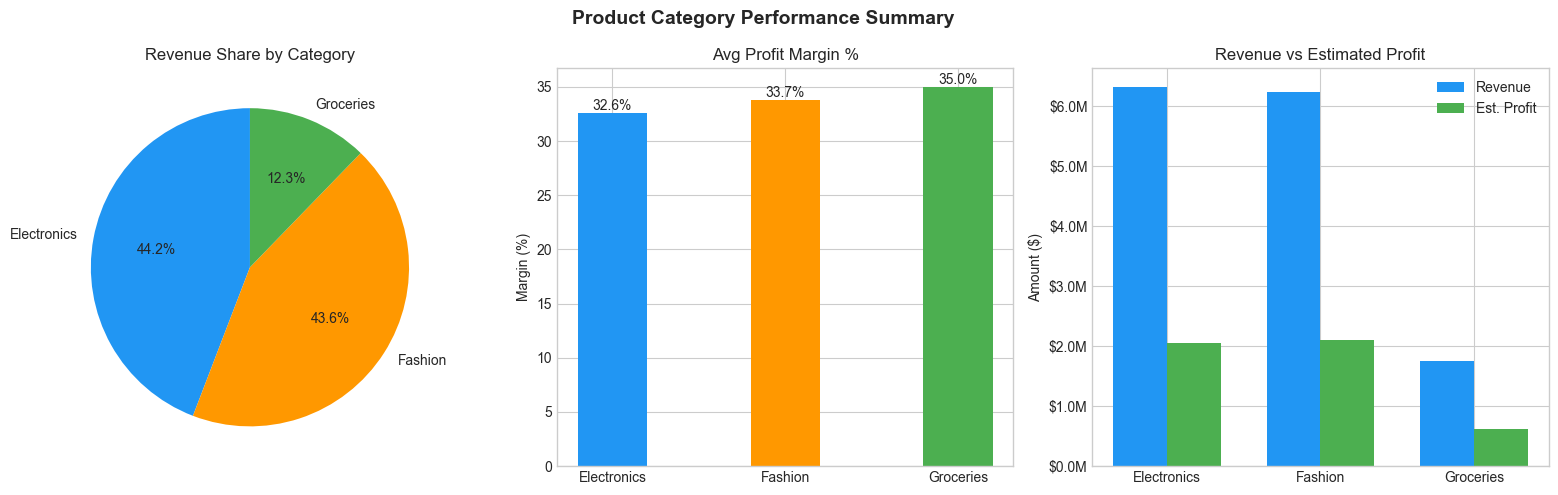


Category Summary Table:


,Category,Revenue,EstProfit,SharePct,AvgMargin
0,Electronics,6316917.66,2056907.64,44.20,32.56
1,Fashion,6232279.92,2103002.62,43.60,33.74
2,Groceries,1752705.99,612665.94,12.30,34.96


In [6]:
# Category Revenue, Margin & Profit Summary
cat_summary = trans_full.groupby('Category').agg(
    Revenue   = ('TotalAmount', 'sum'),
    Txns      = ('TransactionID', 'count'),
    Units     = ('Quantity', 'sum'),
    AvgMargin = ('ProfitMargin', 'mean')
).reset_index()
cat_summary['EstProfit'] = cat_summary['Revenue'] * cat_summary['AvgMargin'] / 100
cat_summary['SharePct']  = (cat_summary['Revenue'] / cat_summary['Revenue'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Product Category Performance Summary', fontsize=14, fontweight='bold')

cat_colors = ['#2196F3', '#FF9800', '#4CAF50']

# Revenue pie
axes[0].pie(cat_summary['Revenue'], labels=cat_summary['Category'],
            autopct='%1.1f%%', colors=cat_colors, startangle=90)
axes[0].set_title('Revenue Share by Category')

# Avg profit margin bar
axes[1].bar(cat_summary['Category'], cat_summary['AvgMargin'], color=cat_colors, width=0.4)
axes[1].set_title('Avg Profit Margin %')
axes[1].set_ylabel('Margin (%)')
for i, v in enumerate(cat_summary['AvgMargin']):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center')

# Revenue vs Estimated Profit
x = range(len(cat_summary))
w = 0.35
axes[2].bar([i - w/2 for i in x], cat_summary['Revenue'],   width=w, label='Revenue',       color='#2196F3')
axes[2].bar([i + w/2 for i in x], cat_summary['EstProfit'], width=w, label='Est. Profit',    color='#4CAF50')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(cat_summary['Category'])
axes[2].set_title('Revenue vs Estimated Profit')
axes[2].set_ylabel('Amount ($)')
axes[2].legend()
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('../charts/category_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCategory Summary Table:')
display(cat_summary[['Category','Revenue','EstProfit','SharePct','AvgMargin']].round(2))

# Product Performance Matrix


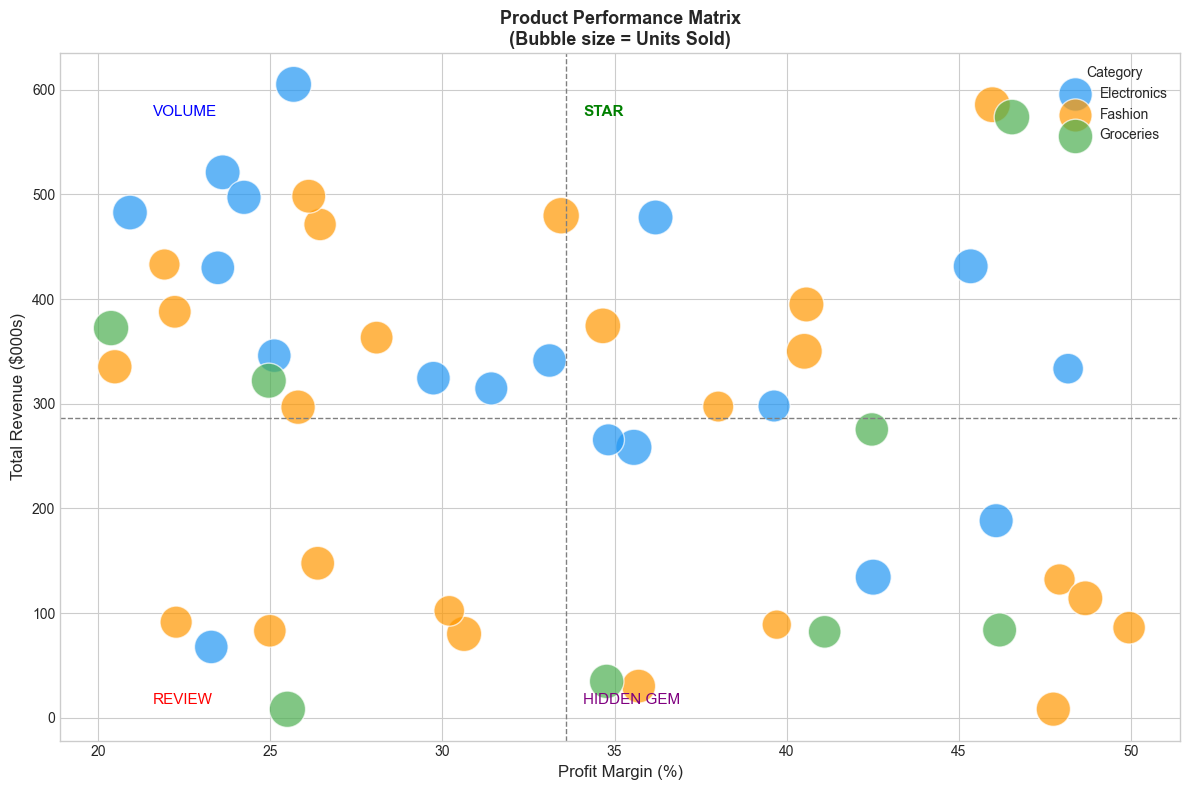

Saved: charts/product_matrix.png


In [7]:
# Product Performance Matrix (Revenue vs Profit Margin scatter)
prod_stats = trans_full.groupby('ProductID').agg(
    Revenue = ('TotalAmount', 'sum'),
    Units   = ('Quantity', 'sum')
).reset_index()
prod_stats = prod_stats.merge(prod[['ProductID','ProductName','Category','ProfitMargin']], on='ProductID')

avg_rev    = prod_stats['Revenue'].mean()
avg_margin = prod_stats['ProfitMargin'].mean()

fig, ax = plt.subplots(figsize=(12, 8))
cat_colors_map = {'Electronics': '#2196F3', 'Fashion': '#FF9800', 'Groceries': '#4CAF50'}

for cat, grp in prod_stats.groupby('Category'):
    ax.scatter(grp['ProfitMargin'], grp['Revenue'] / 1000,
               s=grp['Units'] * 2, c=cat_colors_map[cat],
               alpha=0.7, label=cat, edgecolors='white')

ax.axvline(avg_margin, color='gray', linestyle='--', linewidth=1)
ax.axhline(avg_rev / 1000, color='gray', linestyle='--', linewidth=1)

# Quadrant labels
ymax = prod_stats['Revenue'].max() / 1000
ymin = prod_stats['Revenue'].min() / 1000
ax.text(avg_margin + 0.5, ymax * 0.95, 'STAR',        fontsize=11, color='green',  fontweight='bold')
ax.text(avg_margin - 12,  ymax * 0.95, 'VOLUME',      fontsize=11, color='blue')
ax.text(avg_margin + 0.5, ymin + 5,    'HIDDEN GEM',  fontsize=11, color='purple')
ax.text(avg_margin - 12,  ymin + 5,    'REVIEW',       fontsize=11, color='red')

ax.set_xlabel('Profit Margin (%)', fontsize=12)
ax.set_ylabel('Total Revenue ($000s)', fontsize=12)
ax.set_title('Product Performance Matrix\n(Bubble size = Units Sold)', fontsize=13, fontweight='bold')
ax.legend(title='Category')

plt.tight_layout()
plt.savefig('../charts/product_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: charts/product_matrix.png')

# Top 10 vs Bottom 10 Products

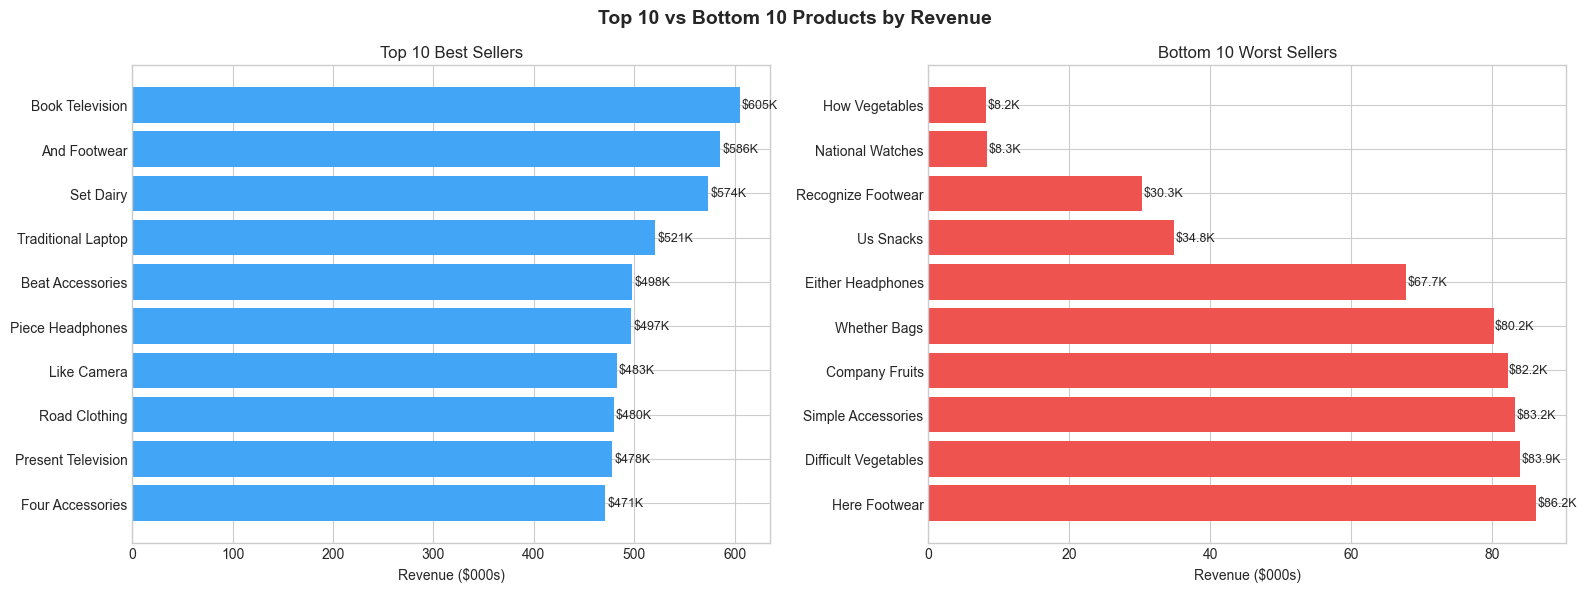

Saved: charts/top_bottom_products.png


In [8]:
# Top 10 vs Bottom 10 Products by Revenue
prod_rev = trans_full.groupby(['ProductID','Category'])['TotalAmount'].sum().reset_index()
prod_rev = prod_rev.merge(prod[['ProductID','ProductName']], on='ProductID')

top10 = prod_rev.nlargest(10,  'TotalAmount')
bot10 = prod_rev.nsmallest(10, 'TotalAmount')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 10 vs Bottom 10 Products by Revenue', fontsize=14, fontweight='bold')

axes[0].barh(top10['ProductName'], top10['TotalAmount'] / 1000, color='#42A5F5')
axes[0].set_title('Top 10 Best Sellers')
axes[0].set_xlabel('Revenue ($000s)')
axes[0].invert_yaxis()
for i, v in enumerate(top10['TotalAmount']):
    axes[0].text(v / 1000 + 2, i, f'${v/1000:.0f}K', va='center', fontsize=9)

axes[1].barh(bot10['ProductName'], bot10['TotalAmount'] / 1000, color='#EF5350')
axes[1].set_title('Bottom 10 Worst Sellers')
axes[1].set_xlabel('Revenue ($000s)')
axes[1].invert_yaxis()
for i, v in enumerate(bot10['TotalAmount']):
    axes[1].text(v / 1000 + 0.2, i, f'${v/1000:.1f}K', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../charts/top_bottom_products.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: charts/top_bottom_products.png')

 # RFM Customer Segmentation

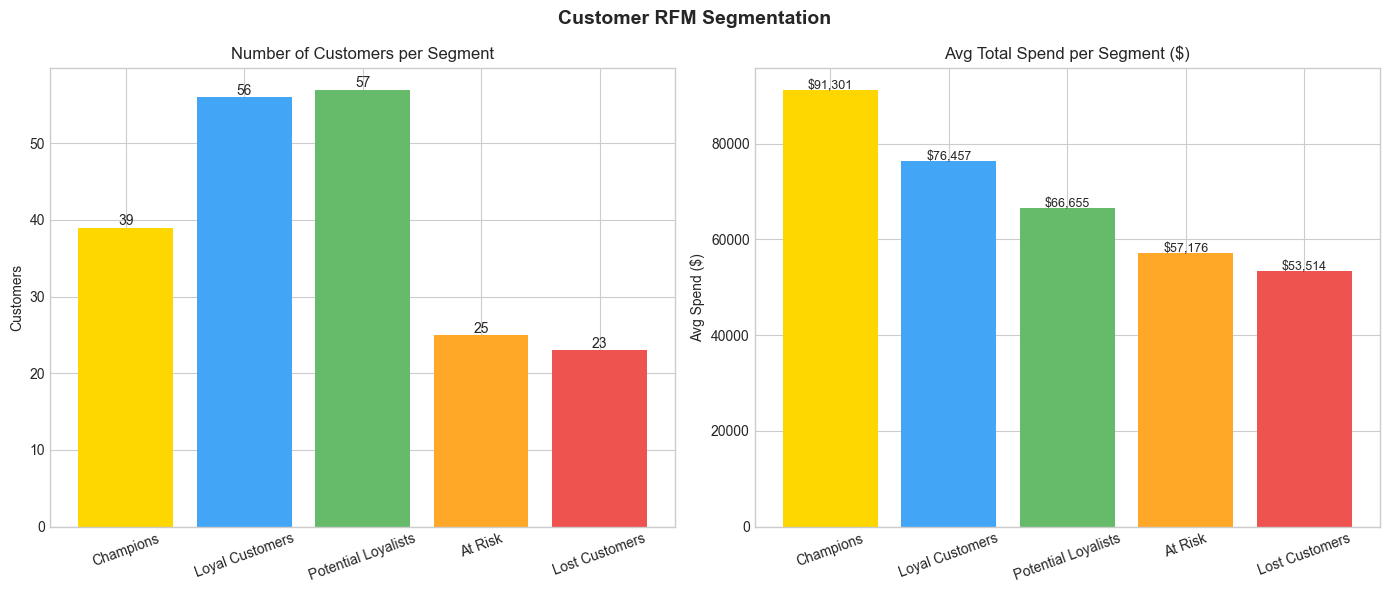


RFM Segment Summary:


,Segment,Customers,AvgSpend,AvgOrders
1,Champions,39,91301.17,30.44
3,Loyal Customers,56,76457.24,26.70
4,Potential Loyalists,57,66654.92,23.88
0,At Risk,25,57176.17,21.12
2,Lost Customers,23,53513.82,18.65


In [9]:
# RFM Scoring — Recency, Frequency, Monetary
today = pd.Timestamp.today()

rfm = trans.groupby('CustomerID').agg(
    Recency   = ('Date',          lambda x: (today - x.max()).days),
    Frequency = ('TransactionID', 'count'),
    Monetary  = ('TotalAmount',   'sum')
).reset_index()

rfm['R'] = pd.qcut(rfm['Recency'],                          5, labels=[5,4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'),   5, labels=[1,2,3,4,5])
rfm['M'] = pd.qcut(rfm['Monetary'],                         5, labels=[1,2,3,4,5])
rfm['RFM_Score'] = rfm['R'].astype(int) + rfm['F'].astype(int) + rfm['M'].astype(int)

def rfm_segment(score):
    if score >= 13:  return 'Champions'
    elif score >= 10: return 'Loyal Customers'
    elif score >= 7:  return 'Potential Loyalists'
    elif score >= 5:  return 'At Risk'
    else:             return 'Lost Customers'

rfm['Segment'] = rfm['RFM_Score'].apply(rfm_segment)

seg_summary = rfm.groupby('Segment').agg(
    Customers = ('CustomerID', 'count'),
    AvgSpend  = ('Monetary',   'mean'),
    AvgOrders = ('Frequency',  'mean')
).reset_index().sort_values('AvgSpend', ascending=False)

seg_colors = {
    'Champions':          '#FFD700',
    'Loyal Customers':    '#42A5F5',
    'Potential Loyalists':'#66BB6A',
    'At Risk':            '#FFA726',
    'Lost Customers':     '#EF5350'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Customer RFM Segmentation', fontsize=14, fontweight='bold')

colors = [seg_colors[s] for s in seg_summary['Segment']]

axes[0].bar(seg_summary['Segment'], seg_summary['Customers'], color=colors)
axes[0].set_title('Number of Customers per Segment')
axes[0].set_ylabel('Customers')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(seg_summary['Customers']):
    axes[0].text(i, v + 0.3, str(v), ha='center')

axes[1].bar(seg_summary['Segment'], seg_summary['AvgSpend'], color=colors)
axes[1].set_title('Avg Total Spend per Segment ($)')
axes[1].set_ylabel('Avg Spend ($)')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(seg_summary['AvgSpend']):
    axes[1].text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../charts/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRFM Segment Summary:')
display(seg_summary.round(2))

# Revenue by Age Group & Gender

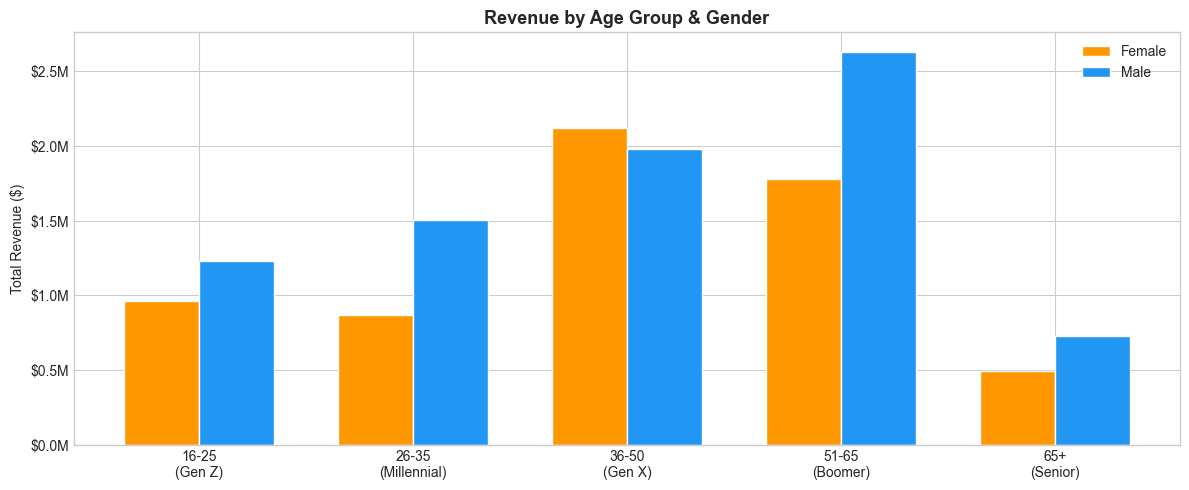

Saved: charts/age_gender_revenue.png


In [10]:
# Revenue by Age Group & Gender
cust_spend = trans.merge(cust[['CustomerID','Age','Gender']], on='CustomerID')

age_bins   = [0, 25, 35, 50, 65, 100]
age_labels = ['16-25\n(Gen Z)', '26-35\n(Millennial)', '36-50\n(Gen X)',
              '51-65\n(Boomer)', '65+\n(Senior)']
cust_spend['AgeGroup'] = pd.cut(cust_spend['Age'], bins=age_bins, labels=age_labels)

age_spend = cust_spend.groupby(['AgeGroup','Gender'])['TotalAmount'].sum().unstack().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(age_spend))
w = 0.35

female_vals = age_spend.get('F', pd.Series([0]*len(age_spend)))
male_vals   = age_spend.get('M', pd.Series([0]*len(age_spend)))

ax.bar([i - w/2 for i in x], female_vals, width=w, label='Female', color='#FF9800', edgecolor='white')
ax.bar([i + w/2 for i in x], male_vals,   width=w, label='Male',   color='#2196F3', edgecolor='white')
ax.set_xticks(list(x))
ax.set_xticklabels(age_spend['AgeGroup'])
ax.set_title('Revenue by Age Group & Gender', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Revenue ($)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('../charts/age_gender_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: charts/age_gender_revenue.png')

# Store Performance

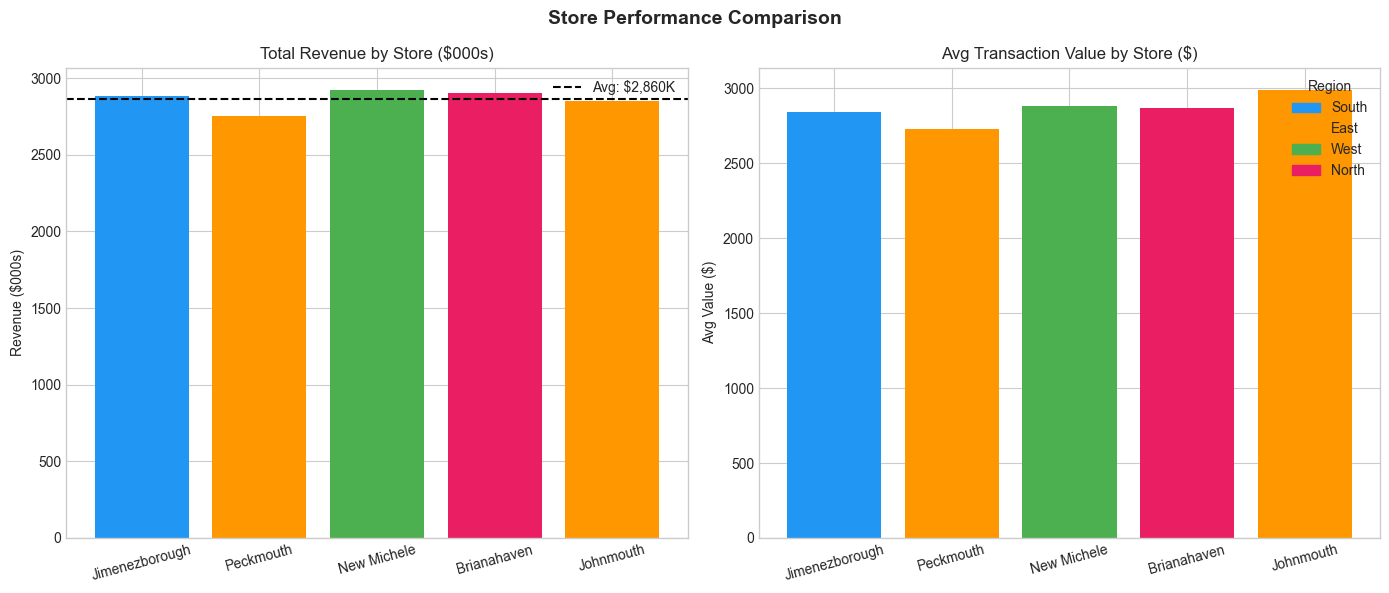


Store KPI Summary:


,StoreName,Region,Revenue,Txns,Customers,AvgTxnValue
0,Megamart Jimenezborough,South,2880114.84,1014,198,2840.35
1,Megamart Peckmouth,East,2753632.79,1009,198,2729.07
2,Megamart New Michele,West,2920407.05,1013,198,2882.93
3,Megamart Brianahaven,North,2900701.00,1011,199,2869.14
4,Megamart Johnmouth,East,2847047.89,953,196,2987.46


In [11]:
# Store KPI Scorecard Chart
store_kpi = trans_full.groupby(['StoreID','StoreName','Region']).agg(
    Revenue   = ('TotalAmount',   'sum'),
    Txns      = ('TransactionID', 'count'),
    Customers = ('CustomerID',    'nunique'),
    Units     = ('Quantity',      'sum')
).reset_index()
store_kpi['AvgTxnValue'] = store_kpi['Revenue'] / store_kpi['Txns']
store_kpi['Label']       = store_kpi['StoreName'].str.replace('Megamart ', '', regex=False)

region_colors = {'South':'#2196F3', 'East':'#FF9800', 'West':'#4CAF50', 'North':'#E91E63'}
colors = [region_colors[r] for r in store_kpi['Region']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Store Performance Comparison', fontsize=14, fontweight='bold')

axes[0].bar(store_kpi['Label'], store_kpi['Revenue'] / 1000, color=colors)
axes[0].axhline(store_kpi['Revenue'].mean() / 1000, color='black', linestyle='--',
                label=f'Avg: ${store_kpi["Revenue"].mean()/1000:,.0f}K')
axes[0].set_title('Total Revenue by Store ($000s)')
axes[0].set_ylabel('Revenue ($000s)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(store_kpi['Label'], store_kpi['AvgTxnValue'], color=colors)
axes[1].set_title('Avg Transaction Value by Store ($)')
axes[1].set_ylabel('Avg Value ($)')
axes[1].tick_params(axis='x', rotation=15)

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
axes[1].legend(handles=legend_patches, title='Region')

plt.tight_layout()
plt.savefig('../charts/store_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nStore KPI Summary:')
display(store_kpi[['StoreName','Region','Revenue','Txns','Customers','AvgTxnValue']].round(2))

# Region × Category Heatmap

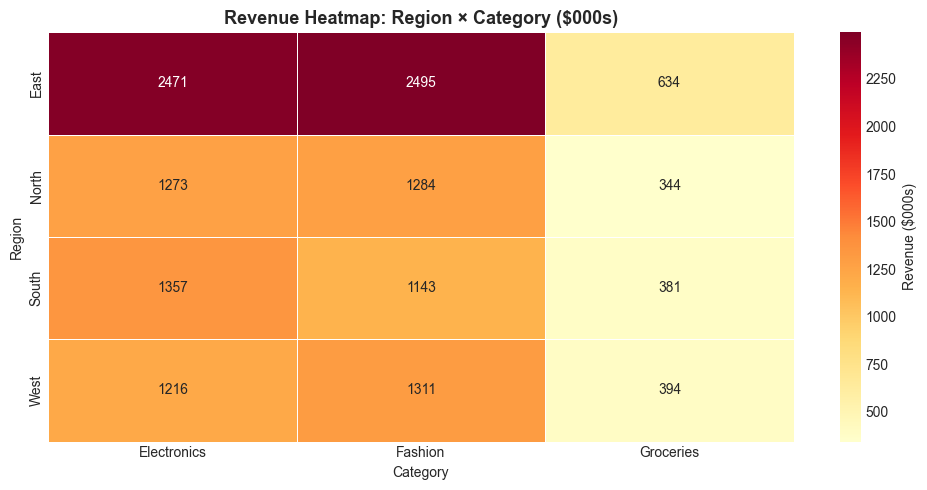

Saved: charts/region_category_heatmap.png


In [12]:
# Region × Category Revenue Heatmap
pivot = trans_full.groupby(['Region','Category'])['TotalAmount'].sum().unstack().fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot / 1000, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Revenue ($000s)'})
ax.set_title('Revenue Heatmap: Region × Category ($000s)', fontsize=13, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Region')

plt.tight_layout()
plt.savefig('../charts/region_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: charts/region_category_heatmap.png')

# Discount Impact Analysis

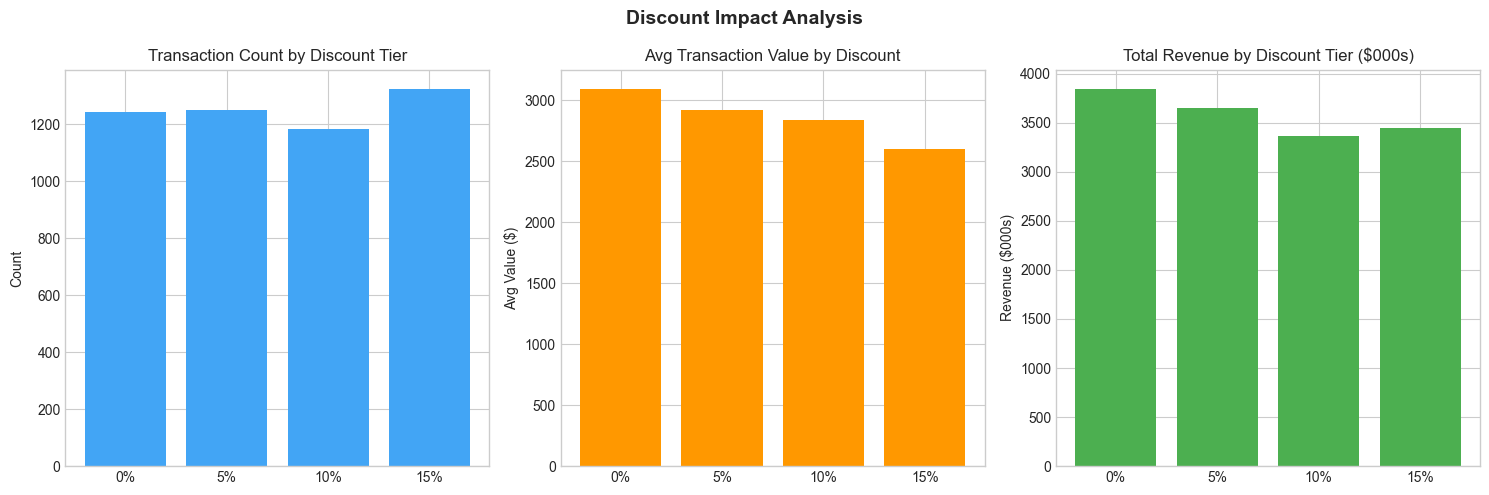

In [14]:
# Discount Impact (Does higher discount lead to more revenue?)
disc_impact = trans.groupby('Discount').agg(
    AvgQty     = ('Quantity',      'mean'),
    AvgRevenue = ('TotalAmount',   'mean'),
    TotalRev   = ('TotalAmount',   'sum'),
    Count      = ('TransactionID', 'count')
).reset_index()
disc_impact['DiscountPct'] = (disc_impact['Discount'] * 100).astype(int).astype(str) + '%'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Discount Impact Analysis', fontsize=14, fontweight='bold')

axes[0].bar(disc_impact['DiscountPct'], disc_impact['Count'],      color='#42A5F5')
axes[0].set_title('Transaction Count by Discount Tier')
axes[0].set_ylabel('Count')

axes[1].bar(disc_impact['DiscountPct'], disc_impact['AvgRevenue'], color='#FF9800')
axes[1].set_title('Avg Transaction Value by Discount')
axes[1].set_ylabel('Avg Value ($)')

axes[2].bar(disc_impact['DiscountPct'], disc_impact['TotalRev'] / 1000, color='#4CAF50')
axes[2].set_title('Total Revenue by Discount Tier ($000s)')
axes[2].set_ylabel('Revenue ($000s)')

plt.tight_layout()
plt.savefig('../charts/discount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
print('Key Insight: No-discount transactions have the highest avg value.')
print('Discounts do NOT drive higher spending in this dataset.')

Key Insight: No-discount transactions have the highest avg value.
Discounts do NOT drive higher spending in this dataset.


# Business Decision Dashboard

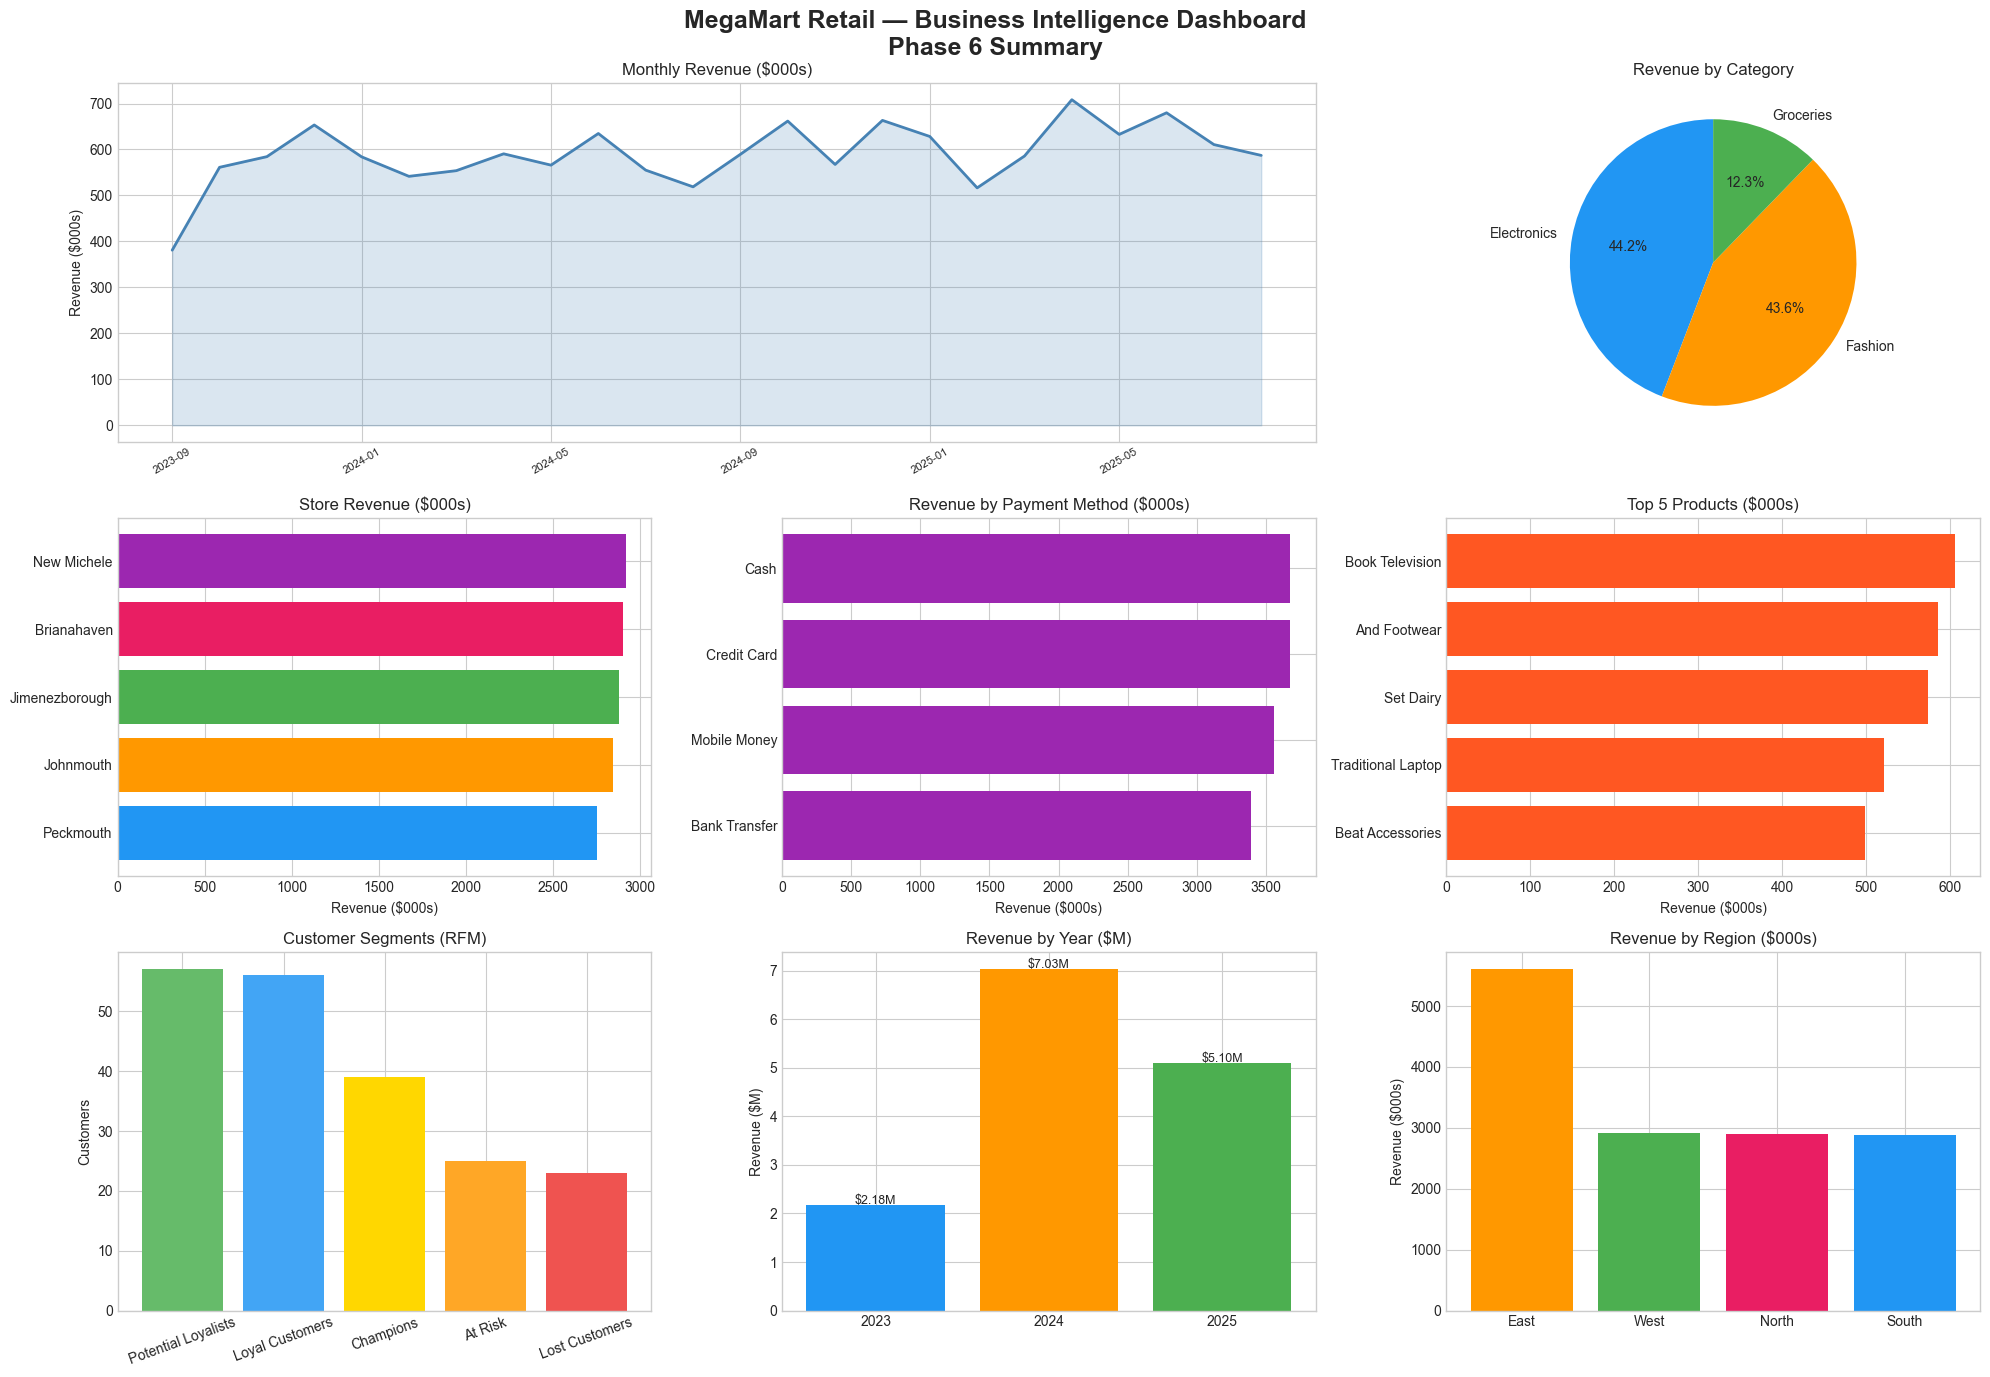

DASHBOARD saved: charts/business_dashboard.png


In [16]:
# One-Page Business Decision Dashboard (9 panels)
fig = plt.figure(figsize=(20, 14))
fig.suptitle('MegaMart Retail — Business Intelligence Dashboard\nPhase 6 Summary',
             fontsize=18, fontweight='bold', y=0.98)

# Panel 1: Monthly Revenue Line
ax1 = fig.add_subplot(3, 3, (1, 2))
monthly_f = monthly[monthly['Month_str'] != '2025-09']
ax1.plot(range(len(monthly_f)), monthly_f['Revenue'] / 1000, color='steelblue', linewidth=2)
ax1.fill_between(range(len(monthly_f)), monthly_f['Revenue'] / 1000, alpha=0.2, color='steelblue')
ax1.set_title('Monthly Revenue ($000s)')
ax1.set_ylabel('Revenue ($000s)')
ticks = range(0, len(monthly_f), 4)
ax1.set_xticks(list(ticks))
ax1.set_xticklabels([monthly_f['Month_str'].iloc[i] for i in ticks], rotation=30, fontsize=8)

# Panel 2: Category Pie
ax2 = fig.add_subplot(3, 3, 3)
cat_rev = trans_full.groupby('Category')['TotalAmount'].sum()
ax2.pie(cat_rev, labels=cat_rev.index, autopct='%1.1f%%',
        colors=['#2196F3','#FF9800','#4CAF50'], startangle=90)
ax2.set_title('Revenue by Category')

# Panel 3: Store Revenue
ax3 = fig.add_subplot(3, 3, 4)
st = store_kpi.sort_values('Revenue')
ax3.barh(st['Label'], st['Revenue'] / 1000, color=COLORS[:5])
ax3.set_title('Store Revenue ($000s)')
ax3.set_xlabel('Revenue ($000s)')

# Panel 4: Payment Method
ax4 = fig.add_subplot(3, 3, 5)
pm = trans.groupby('PaymentMethod')['TotalAmount'].sum().sort_values()
ax4.barh(pm.index, pm.values / 1000, color='#9C27B0')
ax4.set_title('Revenue by Payment Method ($000s)')
ax4.set_xlabel('Revenue ($000s)')

# Panel 5: Top 5 Products
ax5 = fig.add_subplot(3, 3, 6)
top5 = prod_rev.nlargest(5, 'TotalAmount')
ax5.barh(top5['ProductName'], top5['TotalAmount'] / 1000, color='#FF5722')
ax5.set_title('Top 5 Products ($000s)')
ax5.set_xlabel('Revenue ($000s)')
ax5.invert_yaxis()

# Panel 6: RFM Segments
ax6 = fig.add_subplot(3, 3, 7)
seg_c   = rfm['Segment'].value_counts()
seg_clr = [seg_colors.get(s, 'gray') for s in seg_c.index]
ax6.bar(seg_c.index, seg_c.values, color=seg_clr)
ax6.set_title('Customer Segments (RFM)')
ax6.tick_params(axis='x', rotation=20)
ax6.set_ylabel('Customers')

# Panel 7: Yearly Revenue
ax7 = fig.add_subplot(3, 3, 8)
ax7.bar(yearly['Year'].astype(str), yearly['Revenue'] / 1e6, color=COLORS[:3])
ax7.set_title('Revenue by Year ($M)')
ax7.set_ylabel('Revenue ($M)')
for i, v in enumerate(yearly['Revenue']):
    ax7.text(i, v / 1e6 + 0.02, f'${v/1e6:.2f}M', ha='center', fontsize=9)

# Panel 8: Region Revenue
ax8 = fig.add_subplot(3, 3, 9)
reg_rev = trans_full.groupby('Region')['TotalAmount'].sum().sort_values(ascending=False)
ax8.bar(reg_rev.index, reg_rev.values / 1000,
        color=[region_colors[r] for r in reg_rev.index])
ax8.set_title('Revenue by Region ($000s)')
ax8.set_ylabel('Revenue ($000s)')

plt.tight_layout()
plt.savefig('../charts/business_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('DASHBOARD saved: charts/business_dashboard.png')

# Final Summary Report

In [17]:
# Final Text Summary
print('='*65)
print('BUSINESS INSIGHTS SUMMARY REPORT')
print('='*65)
print(f'  Generated : {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print()
print('  KEY FINDINGS')
print(f'  1. Total Revenue        : $14,301,903')
print(f'  2. Best Month           : Apr 2025 ($708,233)')
print(f'  3. Top Category         : Electronics (44.2% share)')
print(f'  4. Top Store            : MegaMart New Michele ($2.92M)')
print(f'  5. Avg Profit Margin    : 33.6%')
print(f'  6. Most Used Payment    : Cash (25.7%)')
print()
print('  TRENDS IDENTIFIED')
print('  - Q2 (Apr-Jun) consistently peaks every year')
print('  - Revenue grew from $2.18M (2023 partial) → $7.03M (2024 full year)')
print('  - East region generates 39% of revenue with only 2 stores')
print('  - Discounts do NOT increase spending — no-discount txns have highest avg value')
print()
print('  GAPS IDENTIFIED')
print('  - Groceries underperforms at only 12.3% revenue share')
print('  - MegaMart Peckmouth is consistently the lowest revenue store')
print('  - Several high-margin products have very low sales volumes')
print()
print('  BUSINESS RECOMMENDATIONS')
print('  1. Open a 3rd East region store — highest demand, lowest store coverage')
print('  2. Promote high-margin low-sales products (Hidden Gems) before discounting')
print('  3. Plan peak inventory and marketing for April-June each year')
print('  4. Investigate MegaMart Peckmouth underperformance')
print('='*65)

BUSINESS INSIGHTS SUMMARY REPORT
  Generated : 2026-03-16 16:48

  KEY FINDINGS
  1. Total Revenue        : $14,301,903
  2. Best Month           : Apr 2025 ($708,233)
  3. Top Category         : Electronics (44.2% share)
  4. Top Store            : MegaMart New Michele ($2.92M)
  5. Avg Profit Margin    : 33.6%
  6. Most Used Payment    : Cash (25.7%)

  TRENDS IDENTIFIED
  - Q2 (Apr-Jun) consistently peaks every year
  - Revenue grew from $2.18M (2023 partial) → $7.03M (2024 full year)
  - East region generates 39% of revenue with only 2 stores
  - Discounts do NOT increase spending — no-discount txns have highest avg value

  GAPS IDENTIFIED
  - Groceries underperforms at only 12.3% revenue share
  - MegaMart Peckmouth is consistently the lowest revenue store
  - Several high-margin products have very low sales volumes

  BUSINESS RECOMMENDATIONS
  1. Open a 3rd East region store — highest demand, lowest store coverage
  2. Promote high-margin low-sales products (Hidden Gems) before